In [2]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [3]:
# handle missing data

from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_frequent = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_frequent.fit_transform(titanic[["embarked"]])

titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
# filling categorical value with numeric value

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [5]:
# creating model

from sklearn.model_selection import train_test_split

X = titanic[features]
y = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [6]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth = 4)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

#accuracy

from sklearn.metrics import accuracy_score

print("Training accuracy: ", accuracy_score(y_train, y_pred_train)*100, "%")
print("Testing accuracy: ", accuracy_score(y_test, y_pred_test)*100, "%")

Training accuracy:  84.75120385232745 %
Testing accuracy:  82.46268656716418 %


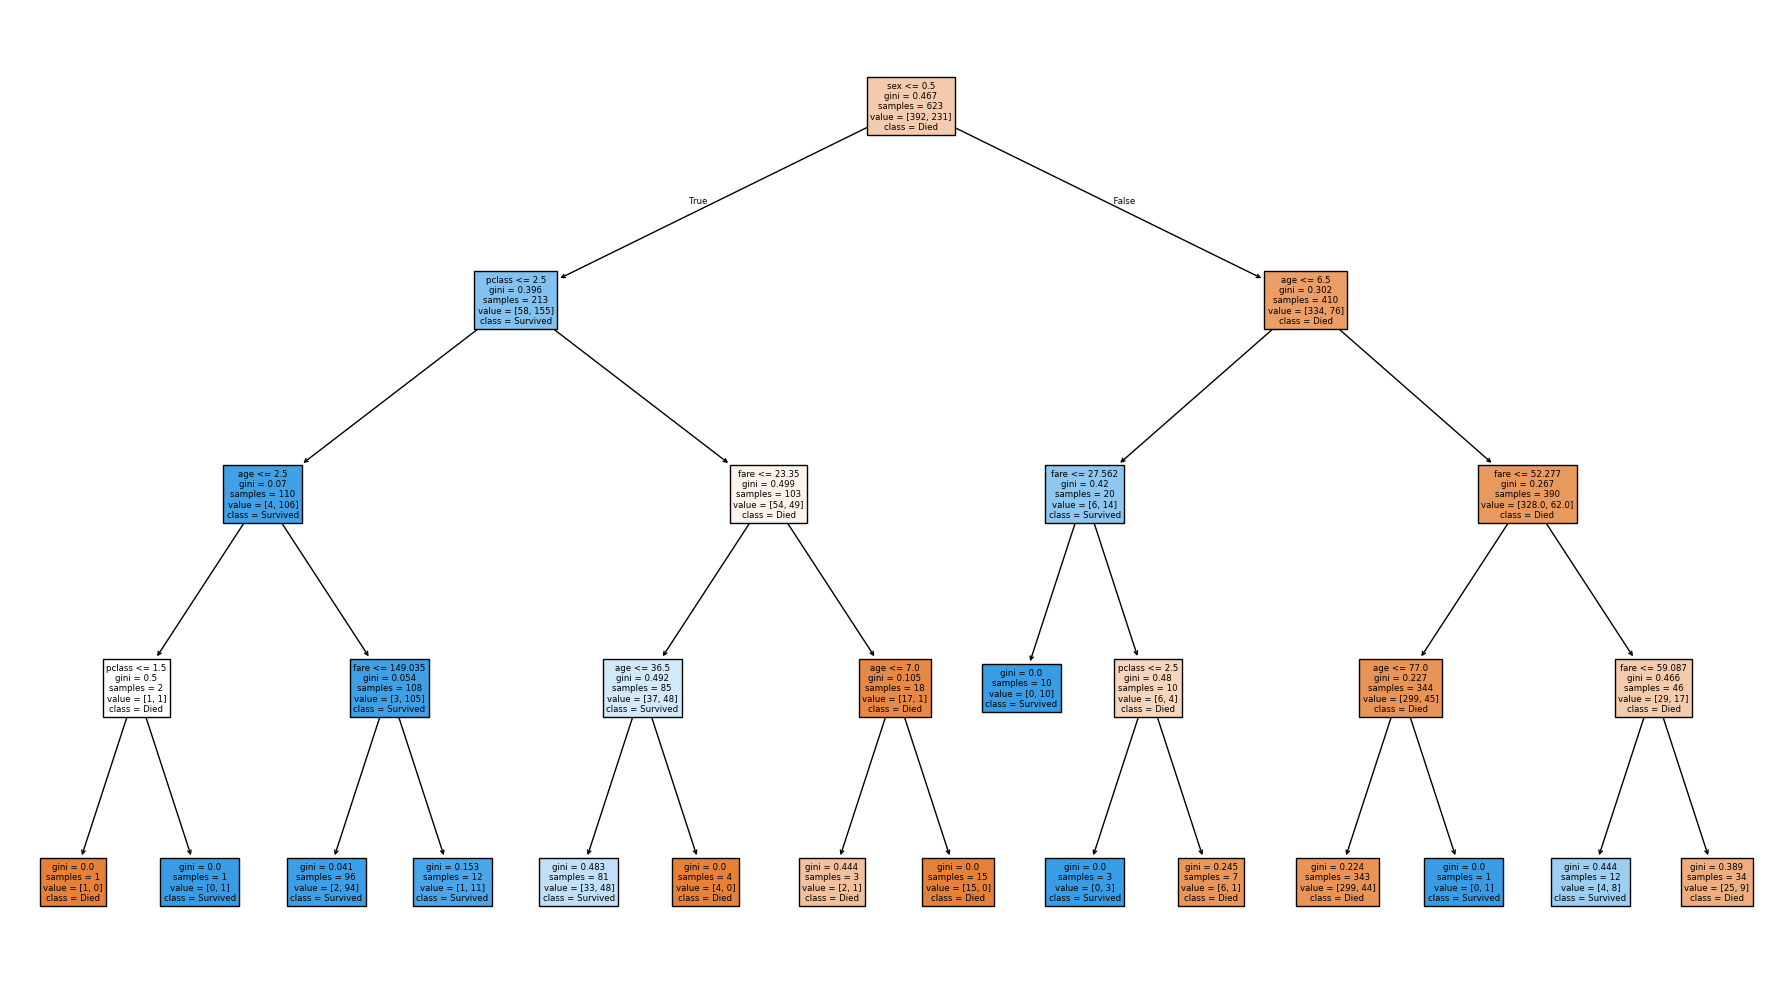

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 10))
plot_tree(model, feature_names = X.columns, class_names = ["Died", "Survived"], filled = True)

plt.tight_layout()

In [8]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 501,
    oob_score = True,
    max_depth = 4
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("OOB Score:", rf.oob_score_ * 100, "%")
print("Testing Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

OOB Score: 82.5040128410915 %
Testing Accuracy: 80.97014925373134 %


In [9]:
titanic.shape

(891, 15)

In [10]:
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators = 201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("acccuracy: ", accuracy_score(y_test, y_pred))

acccuracy:  0.7649253731343284


In [11]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7947761194029851
